<a href="https://colab.research.google.com/github/ShilpaVasista/Exploratory-Data-Analytics/blob/main/module_4_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Q1: Consider the following Python code:

```
import pandas as pd
df = pd.DataFrame({
    'timestamp': ['2017-01-14', '2017-01-15', '2017-01-16',
                  '2017-01-17', '2017-01-18', '2017-02-01',
                  '2017-02-15', '2017-02-28'],
    'load_MW':   [4200, 4350, 4100, 4500, 4250, 3900, 4050, 3800]
})
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)
print(df.loc['2017-01'])
print(df.loc['2017-01-15':'2017-01-18'])
print(df.resample('M').mean())

```

(i) Write the output of each of the three print statements.

(ii) Distinguish between loc-based date slicing and resample() with monthly frequency.



In [ ]:
import pandas as pd
df = pd.DataFrame({
    'timestamp': ['2017-01-14', '2017-01-15', '2017-01-16',
                  '2017-01-17', '2017-01-18', '2017-02-01',
                  '2017-02-15', '2017-02-28'],
    'load_MW':   [4200, 4350, 4100, 4500, 4250, 3900, 4050, 3800]
})
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)
print(df.loc['2017-01'])
print(df.loc['2017-01-15':'2017-01-18'])
print(df.resample('M').mean())

            load_MW
timestamp          
2017-01-14     4200
2017-01-15     4350
2017-01-16     4100
2017-01-17     4500
2017-01-18     4250
            load_MW
timestamp          
2017-01-15     4350
2017-01-16     4100
2017-01-17     4500
2017-01-18     4250
                load_MW
timestamp              
2017-01-31  4280.000000
2017-02-28  3916.666667


/tmp/ipykernel_1352/3334423582.py:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  print(df.resample('M').mean())


#### (ii) Distinction between `loc`-based date slicing and `resample()` with monthly frequency

*   **`loc`-based date slicing (`df.loc['2017-01']` and `df.loc['2017-01-15':'2017-01-18']`)**:
    *   `loc`-based slicing is used to **select a subset of rows** from the DataFrame based on date labels in the index. It returns the original data points that fall within the specified date range or period.
    *   It's a form of **filtering** the data.
    *   For example, `df.loc['2017-01']` selects all rows with dates in January 2017, and `df.loc['2017-01-15':'2017-01-18']` selects rows from January 15th to January 18th, inclusive.

*   **`resample('M').mean()`**:
    *   `resample()` is used to **change the frequency** of the time series data. When used with an aggregation function like `mean()`, it **groups the data by the new frequency** (e.g., monthly) and then calculates the specified aggregate for each group.
    *   It's a form of **aggregation or transformation** of the data, which often reduces the number of rows and summarizes the data.
    *   For example, `df.resample('M').mean()` groups all data points by month and then calculates the average `load_MW` for each month, resulting in a new DataFrame with one row per month, representing the monthly average.

Q2: Consider the following power consumption dataset:

```
import pandas as pd
df = pd.DataFrame({
    'timestamp': ['2017-01-01', '2017-01-02', '2017-01-02',
                  '2017-01-03', '2017-01-04', '2017-01-05'],
    'load_MW':   [4200, 4350, 4350, None, 4250, 4100]
})
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)
print(df)
```

Write Python code to:

(i) Detect and remove the duplicate timestamp entry.

(ii) Identify and handle the NaN value using forward fill.


In [ ]:
import pandas as pd
df = pd.DataFrame({
    'timestamp': ['2017-01-01', '2017-01-02', '2017-01-02',
                  '2017-01-03', '2017-01-04', '2017-01-05'],
    'load_MW':   [4200, 4350, 4350, None, 4250, 4100]
})
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

print("Original DataFrame:")
print(df)

# (i) Detect and remove the duplicate timestamp entry
# To detect duplicates in the index, we can use df.index.duplicated()
# To keep the first occurrence and remove subsequent duplicates:
df_no_duplicates = df[~df.index.duplicated(keep='first')]
print("\nDataFrame after removing duplicate timestamps (keeping first occurrence):")
print(df_no_duplicates)

# (ii) Identify and handle the NaN value using forward fill
# Forward fill propagates the last valid observation forward to next valid observation
df_filled = df_no_duplicates.ffill()
print("\nDataFrame after forward filling NaN values:")
print(df_filled)

Original DataFrame:
            load_MW
timestamp          
2017-01-01   4200.0
2017-01-02   4350.0
2017-01-02   4350.0
2017-01-03      NaN
2017-01-04   4250.0
2017-01-05   4100.0

DataFrame after removing duplicate timestamps (keeping first occurrence):
            load_MW
timestamp          
2017-01-01   4200.0
2017-01-02   4350.0
2017-01-03      NaN
2017-01-04   4250.0
2017-01-05   4100.0

DataFrame after forward filling NaN values:
            load_MW
timestamp          
2017-01-01   4200.0
2017-01-02   4350.0
2017-01-03   4350.0
2017-01-04   4250.0
2017-01-05   4100.0


Q3: Consider the following power consumption dataset:
```
import pandas as pd
import matplotlib.pyplot as plt
df = pd.DataFrame({
    'timestamp': ['2017-01-01', '2017-01-02', '2017-01-03',
                  '2017-01-04', '2017-01-05'],
    'load_MW':   [4200, 4350, 4100, 4500, 4250]
})
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)
```
Using the provided `df` DataFrame with its `timestamp` as the index, write Python code to perform the following time series analyses and visualizations:

1.  **Visualize `load_MW` as a line chart with customisations:**
    *   Generate a line chart for the `load_MW` column.
    *   Include a clear and descriptive title for the chart.
    *   Provide informative labels for both the X-axis (Date/Timestamp) and Y-axis (Load in MW).
    *   Add a grid to the plot for enhanced readability.
    *   Display the generated plot.

2.  **Calculate and visualize daily changes:**
    *   Compute the daily difference (change) in `load_MW`.
    *   Visualize these daily changes as a line chart.
    *   Include an appropriate title and axis labels.



3.  **Interpret the visualizations:**
    *   Based on the plots, describe any observed trends or patterns in the `load_MW` data over this short period.

### Solution for Q3

#### 1. Visualize `load_MW` as a line chart with customisations

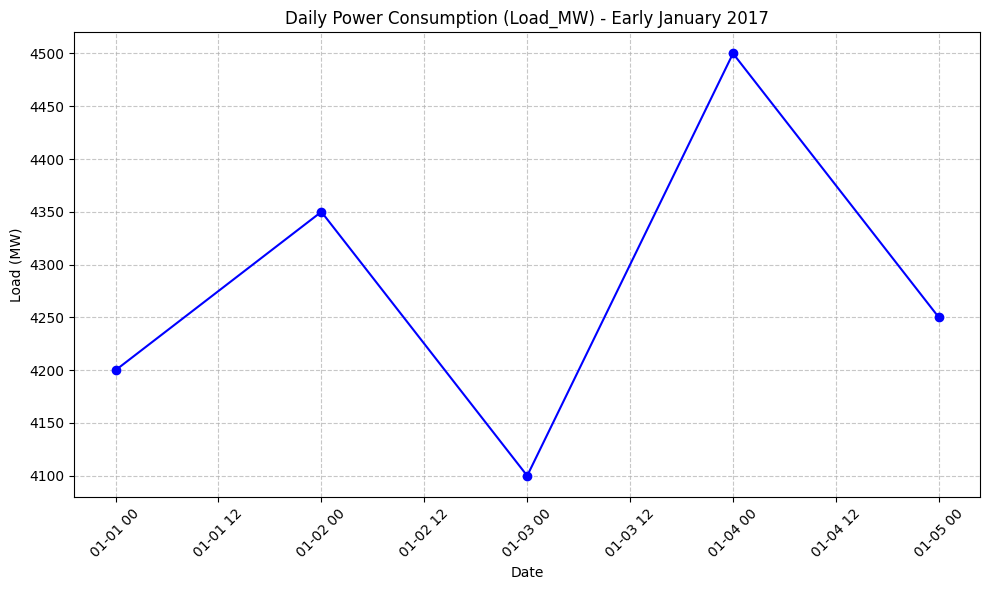

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Re-create the DataFrame as per Q3's context, if not already in kernel
df = pd.DataFrame({
    'timestamp': ['2017-01-01', '2017-01-02', '2017-01-03',
                  '2017-01-04', '2017-01-05'],
    'load_MW':   [4200, 4350, 4100, 4500, 4250]
})
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

plt.figure(figsize=(10, 6))
plt.plot(df.index, df['load_MW'], marker='o', linestyle='-', color='blue')
plt.title('Daily Power Consumption (Load_MW) - Early January 2017')
plt.xlabel('Date')
plt.ylabel('Load (MW)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 2. Calculate and visualize daily changes

timestamp
2017-01-01      NaN
2017-01-02    150.0
2017-01-03   -250.0
2017-01-04    400.0
2017-01-05   -250.0
Name: daily_change, dtype: float64


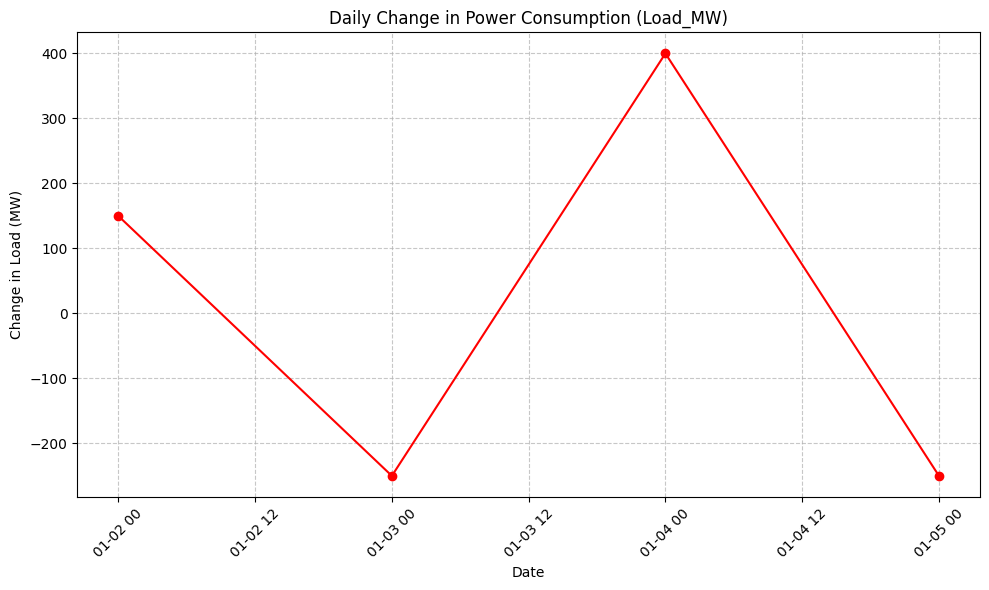

In [ ]:
import matplotlib.pyplot as plt

# Calculate daily changes in load_MW
df['daily_change'] = df['load_MW'].diff()
print(df['daily_change'])

plt.figure(figsize=(10, 6))
plt.plot(df.index, df['daily_change'], marker='o', linestyle='-', color='red')
plt.title('Daily Change in Power Consumption (Load_MW)')
plt.xlabel('Date')
plt.ylabel('Change in Load (MW)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 3. Interpret the visualizations

Based on the plots for `load_MW` and its daily changes over the period of January 1st to January 5th, 2017:

*   **Load_MW Visualization**: The first plot shows the raw power consumption data. We can observe a fluctuating pattern. The load starts at 4200 MW, increases to 4350 MW, drops to 4100 MW, peaks at 4500 MW, and then decreases slightly to 4250 MW. This short-term data does not clearly indicate a strong upward or downward trend, but rather day-to-day variability.

*   **Daily Changes Visualization**: The second plot highlights the day-to-day fluctuations more clearly.
    *   Jan 1 to Jan 2: Load increased by 150 MW.
    *   Jan 2 to Jan 3: Load decreased by 250 MW.
    *   Jan 3 to Jan 4: Load increased significantly by 400 MW.
    *   Jan 4 to Jan 5: Load decreased by 250 MW.
    
    The daily changes reveal that the largest increase occurred between Jan 3 and Jan 4, and the largest decreases occurred between Jan 2-3 and Jan 4-5. The changes are quite volatile over this very short period, suggesting significant variation in consumption from one day to the next without a consistent pattern emerging from only 5 days of data.

Q4: Consider the following Python code:
```
import pandas as pd
index = pd.date_range('2023-01-01', periods=10, freq='D')
df = pd.DataFrame({
    'Load_MW': [4200, 4350, 4100, 4500, 4250,
                3900, 4050, 3800, 4150, 4300]
}, index=index)
print(df.resample('W').mean())
print(df.resample('W').sum())
print(df.resample('ME').max())
```
Write the output of each of the three print statements.


In [ ]:
import pandas as pd
index = pd.date_range('2026-04-26', periods=10, freq='D')
df = pd.DataFrame({
    'Load_MW': [4200, 4350, 4100, 4500, 4250,
                3900, 4050, 3800, 4150, 4300]
}, index=index)

print("Original Dataframe")
print(df)

print("Output of df.resample('W').mean():")
print(df.resample('W').mean())
print("\nOutput of df.resample('W').sum():")
print(df.resample('W').sum())
print("\nOutput of df.resample('ME').max():")
print(df.resample('ME').max())

Original Dataframe
            Load_MW
2026-04-26     4200
2026-04-27     4350
2026-04-28     4100
2026-04-29     4500
2026-04-30     4250
2026-05-01     3900
2026-05-02     4050
2026-05-03     3800
2026-05-04     4150
2026-05-05     4300
Output of df.resample('W').mean():
                Load_MW
2026-04-26  4200.000000
2026-05-03  4135.714286
2026-05-10  4225.000000

Output of df.resample('W').sum():
            Load_MW
2026-04-26     4200
2026-05-03    28950
2026-05-10     8450

Output of df.resample('M').max():
            Load_MW
2026-04-30     4500
2026-05-31     4300


Q5: Consider the following power consumption dataset:

```
import pandas as pd
df = pd.DataFrame({
    'timestamp': ['2017-01-10', '2017-01-20', '2017-02-10',
                  '2017-02-20', '2017-03-10', '2017-03-20'],
    'load_MW':   [4200, 4350, 3900, 4050, 4500, 4250]
})
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)
```
Write Python code to perform the following operations and interpret each result:

(i) Compute monthly mean of load_MW.

(ii) Extract the month component from the DatetimeIndex and compute average load_MW per month.


In [1]:
import pandas as pd

df = pd.DataFrame({
    'timestamp': ['2017-01-10', '2017-01-20', '2017-02-10',
                  '2017-02-20', '2017-03-10', '2017-03-20'],
    'load_MW':   [4200, 4350, 3900, 4050, 4500, 4250]
})
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

print("Original DataFrame:")
print(df)

# (i) Compute monthly mean of load_MW
monthly_mean_resample = df.resample('ME').mean()
print("\n(i) Monthly mean of load_MW (using resample('M').mean()):")
print(monthly_mean_resample)
print("Interpretation: This output shows the average load_MW for each month based on the data points available. For January 2017, the average is (4200 + 4350) / 2 = 4275.0. Similarly for February and March.")
print()
print()

# (ii) Extract the month component from the DatetimeIndex and compute average load_MW per month.
# Extract month as an integer
df['month'] = df.index.month
print("\n(ii) Average load_MW per month (using groupby and extracted month component):")
print("Sample dataframe after adding month column")
print(df)
print()
monthly_mean_groupby = df.groupby('month')['load_MW'].mean()

print(monthly_mean_groupby)
print("Interpretation: This output shows the average load_MW for each distinct month number found in the dataset. Month 1 (January), Month 2 (February), and Month 3 (March) have their respective averages calculated. The results are identical to resample('M').mean() in this specific dataset because each month is represented, but resample handles the time series aspect more robustly, even if data points are sparse or irregular within a month.")

Original DataFrame:
            load_MW
timestamp          
2017-01-10     4200
2017-01-20     4350
2017-02-10     3900
2017-02-20     4050
2017-03-10     4500
2017-03-20     4250

(i) Monthly mean of load_MW (using resample('M').mean()):
            load_MW
timestamp          
2017-01-31   4275.0
2017-02-28   3975.0
2017-03-31   4375.0
Interpretation: This output shows the average load_MW for each month based on the data points available. For January 2017, the average is (4200 + 4350) / 2 = 4275.0. Similarly for February and March.



(ii) Average load_MW per month (using groupby and extracted month component):
Sample dataframe after adding month column
            load_MW  month
timestamp                 
2017-01-10     4200      1
2017-01-20     4350      1
2017-02-10     3900      2
2017-02-20     4050      2
2017-03-10     4500      3
2017-03-20     4250      3

month
1    4275.0
2    3975.0
3    4375.0
Name: load_MW, dtype: float64
Interpretation: This output shows the average lo

Describe the steps involved in performing EDA on the Open Power System dataset. Provide a step-by-step explanation for each of the following:

(i) Loading the dataset and setting up time-based indexing using parse_dates and index_col.

(ii) Data cleaning — identifying and handling NaN values using dropna() and fillna().

(iii) Visualising monthly trends by resampling the data using resample('M').mean() and plotting using df.plot().


### Solution for `novqybI2V9k_`

Describe the steps involved in performing EDA on the Open Power System dataset.

#### (i) Loading the dataset and setting up time-based indexing using `parse_dates` and `index_col`.

1.  **Import Pandas**: Start by importing the pandas library.
    ```python
    import pandas as pd
    ```
2.  **Load the Dataset**: Use `pd.read_csv()` to load your dataset. The `parse_dates` parameter should be set to a list of column names that contain date/time information, which pandas will then try to convert into `datetime` objects. The `index_col` parameter specifies the column to be used as the DataFrame index. For time series, this is typically the timestamp column.
    ```python
    # Assuming your CSV is named 'opsd_germany_daily.csv' and has a 'Date' column for timestamps
    df = pd.read_csv('opsd_germany_daily.csv', parse_dates=['Date'], index_col='Date')
    ```
3.  **Verify Index**: After loading, it's good practice to verify that the index is indeed a `DatetimeIndex` and that the data types are correct.
    ```python
    print(df.info())
    ```

#### (ii) Data cleaning — identifying and handling NaN values using `dropna()` and `fillna()`.

1.  **Identify Missing Values**: Check for `NaN` (Not a Number) values in your DataFrame. This gives an idea of where data is missing.
    ```python
    print(df.isnull().sum()) # Shows count of NaNs per column
    ```
2.  **Handling Missing Values (Strategy depends on context)**:
    *   **`dropna()` (Drop rows/columns with NaNs)**: If only a small percentage of rows have missing data, or if an entire column is mostly empty and not crucial for analysis, you can drop them.
        ```python
        # Drop rows with any NaN values
        df_cleaned_drop_rows = df.dropna()
        # Drop columns with any NaN values
        df_cleaned_drop_cols = df.dropna(axis=1)
        ```
    *   **`fillna()` (Fill NaNs)**: More commonly, you'll want to impute missing values. Common strategies include:
        *   **Forward Fill (`ffill()`)**: Propagates the last valid observation forward to next valid observation. Suitable for time series where you assume the value remains constant until a new one appears.
            ```python
            df_filled_ffill = df.ffill()
            ```
        *   **Backward Fill (`bfill()`)**: Propagates the next valid observation backward to the current missing value. Useful if future values are more representative.
            ```python
            df_filled_bfill = df.bfill()
            ```
        *   **Mean/Median/Mode Imputation**: Fill `NaN`s with the mean, median, or mode of the column. This can be done for numerical data.
            ```python
            # Example for a specific column
            df['SomeColumn'] = df['SomeColumn'].fillna(df['SomeColumn'].mean())
            ```
        *   **Interpolation**: For time series, interpolation (e.g., linear) is often a good choice, as it estimates missing values based on surrounding points.
            ```python
            df_interpolated = df.interpolate(method='linear')
            ```

#### (iii) Visualising monthly trends by resampling the data using `resample('M').mean()` and plotting using `df.plot()`.

1.  **Resample to Monthly Frequency**: Use the `resample('M')` method on your DataFrame (which should have a `DatetimeIndex`) to group data by month. Then apply an aggregation function, commonly `mean()`, to summarize the data for each month.
    ```python
    # Assuming 'df' is your cleaned DataFrame with a DatetimeIndex
    monthly_mean_data = df.resample('M').mean()
    ```
2.  **Visualize Monthly Trends**: Use the `.plot()` method directly on the resampled DataFrame. Pandas will automatically use the `DatetimeIndex` for the x-axis and plot each numerical column as a separate line.
    ```python
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 6))
    monthly_mean_data['load_MW'].plot(title='Monthly Average Load (MW)') # Plotting a specific column if many exist
    plt.xlabel('Date')
    plt.ylabel('Average Load (MW)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # If you want to plot all numerical columns in the resampled data
    # monthly_mean_data.plot(figsize=(12, 6), title='Monthly Average Trends')
    # plt.xlabel('Date')
    # plt.ylabel('Average Value')
    # plt.grid(True, linestyle='--', alpha=0.7)
    # plt.tight_layout()
    # plt.show()
    ```
This process effectively transforms daily or hourly data into a monthly view, making it easier to observe seasonal patterns and long-term trends.

## Resources

### Common `resample()` Frequencies in Pandas

When using `resample()` in pandas, you specify an offset alias string for the frequency. Here are some common frequencies:

*   **Daily:** 'D' (Calendar day frequency)
*   **Weekly:** 'W' (Weekly frequency)
*   **Monthly:** 'ME' (Month end frequency) or 'MS' (Month start frequency)
*   **Quarterly:** 'QE' (Quarter end frequency) or 'QS' (Quarter start frequency)
*   **Annual:** 'YE' (Year end frequency) or 'YS' (Year start frequency)
*   **Hourly:** 'H' (Hourly frequency)
*   **Minutes:** 'min' (Minute frequency)
*   **Seconds:** 'S' (Second frequency)
*   **Business Day:** 'B' (Business day frequency)
*   **Custom Frequencies:** You can also specify multiples, e.g., '2D' for every two days, '3H' for every three hours.
*   **Anchored Frequencies:** E.g., 'W-MON' for weekly frequency anchored on Monday.

## Exercises on Time Series Analysis in Pandas

### Exercise 1: Understanding `loc` Slicing and Resampling Output

Consider the following Python code creating a DataFrame with daily temperature data:

```python
import pandas as pd
df_ex1 = pd.DataFrame({
    'date': ['2023-03-01', '2023-03-02', '2023-03-03', '2023-03-04', '2023-03-05',
             '2023-03-06', '2023-03-07', '2023-04-01', '2023-04-02', '2023-04-03'],
    'temperature_c': [10, 12, 11, 13, 10, 9, 11, 15, 16, 14]
})
df_ex1['date'] = pd.to_datetime(df_ex1['date'])
df_ex1.set_index('date', inplace=True)

print(df_ex1.loc['2023-03-03':'2023-03-06'])
print(df_ex1.resample('W').max())
print(df_ex1.loc['2023-04'])
```

Write the output of each of the three `print` statements.


2023 March Calendar

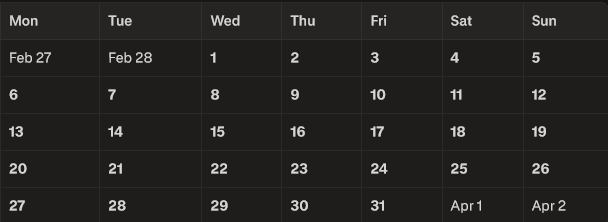

In [6]:
import pandas as pd
df_ex1 = pd.DataFrame({
    'date': ['2023-03-01', '2023-03-02', '2023-03-03', '2023-03-04', '2023-03-05',
             '2023-03-06', '2023-03-07', '2023-04-01', '2023-04-02', '2023-04-03'],
    'temperature_c': [10, 12, 11, 13, 10, 9, 11, 15, 16, 14]
})
df_ex1['date'] = pd.to_datetime(df_ex1['date'])
df_ex1.set_index('date', inplace=True)

print(df_ex1.loc['2023-03-03':'2023-03-06'])
print(df_ex1.resample('W').max())
print(df_ex1.loc['2023-04'])

            temperature_c
date                     
2023-03-03             11
2023-03-04             13
2023-03-05             10
2023-03-06              9
            temperature_c
date                     
2023-03-05           13.0
2023-03-12           11.0
2023-03-19            NaN
2023-03-26            NaN
2023-04-02           16.0
2023-04-09           14.0
            temperature_c
date                     
2023-04-01             15
2023-04-02             16
2023-04-03             14


### Exercise 2: Data Cleaning - Duplicates and Missing Values

You are given a simulated sensor data DataFrame with some common issues:

```python
import pandas as pd
df_ex2 = pd.DataFrame({
    'timestamp': ['2024-01-01 10:00:00', '2024-01-01 11:00:00', '2024-01-01 11:00:00',
                  '2024-01-01 12:00:00', '2024-01-01 13:00:00', '2024-01-01 14:00:00',
                  '2024-01-01 15:00:00', '2024-01-01 16:00:00'],
    'sensor_value': [25.1, 25.5, 25.5, None, 26.0, 25.8, None, 26.1]
})
df_ex2['timestamp'] = pd.to_datetime(df_ex2['timestamp'])
df_ex2.set_index('timestamp', inplace=True)

print("Original DataFrame:")
print(df_ex2)
```

Write Python code to:

(i) Remove any duplicate `timestamp` entries, keeping the first occurrence.

(ii) Fill the `NaN` values in the `sensor_value` column using backward fill (`bfill`).

(iii) Print the DataFrame after each cleaning step.

In [2]:
import pandas as pd
df_ex2 = pd.DataFrame({
    'timestamp': ['2024-01-01 10:00:00', '2024-01-01 11:00:00', '2024-01-01 11:00:00',
                  '2024-01-01 12:00:00', '2024-01-01 13:00:00', '2024-01-01 14:00:00',
                  '2024-01-01 15:00:00', '2024-01-01 16:00:00'],
    'sensor_value': [25.1, 25.5, 25.5, None, 26.0, 25.8, None, 26.1]
})
df_ex2['timestamp'] = pd.to_datetime(df_ex2['timestamp'])
df_ex2.set_index('timestamp', inplace=True)

print("Original DataFrame:")
print(df_ex2)

# (i) Remove duplicate timestamps
df_ex2_no_duplicates = df_ex2[~df_ex2.index.duplicated(keep='first')]
print("\nDataFrame after removing duplicates:")
print(df_ex2_no_duplicates)

# (ii) Fill NaN values using backward fill
df_ex2_cleaned = df_ex2_no_duplicates.bfill()
print("\nDataFrame after backward filling NaNs:")
print(df_ex2_cleaned)

Original DataFrame:
                     sensor_value
timestamp                        
2024-01-01 10:00:00          25.1
2024-01-01 11:00:00          25.5
2024-01-01 11:00:00          25.5
2024-01-01 12:00:00           NaN
2024-01-01 13:00:00          26.0
2024-01-01 14:00:00          25.8
2024-01-01 15:00:00           NaN
2024-01-01 16:00:00          26.1

DataFrame after removing duplicates:
                     sensor_value
timestamp                        
2024-01-01 10:00:00          25.1
2024-01-01 11:00:00          25.5
2024-01-01 12:00:00           NaN
2024-01-01 13:00:00          26.0
2024-01-01 14:00:00          25.8
2024-01-01 15:00:00           NaN
2024-01-01 16:00:00          26.1

DataFrame after backward filling NaNs:
                     sensor_value
timestamp                        
2024-01-01 10:00:00          25.1
2024-01-01 11:00:00          25.5
2024-01-01 12:00:00          26.0
2024-01-01 13:00:00          26.0
2024-01-01 14:00:00          25.8
2024-01-01 15:00:0

### Exercise 3: Visualizing Time Series Trends (Chart Analysis)

Given the following DataFrame representing daily website traffic:

```python
import pandas as pd
import matplotlib.pyplot as plt

df_ex3 = pd.DataFrame({
    'date': pd.date_range(start='2023-01-01', periods=30, freq='D'),
    'page_views': [1200, 1250, 1180, 1300, 1400, 1500, 1600, 1220, 1280, 1150,
                   1350, 1450, 1550, 1650, 1200, 1260, 1190, 1310, 1420, 1530,
                   1630, 1210, 1270, 1160, 1320, 1430, 1540, 1640, 1230, 1290]
})
df_ex3.set_index('date', inplace=True)
```

(i) Write Python code to generate a line plot of `page_views` over time. Ensure the plot has a title, labeled axes, and a grid.

(ii) Based on the generated plot, describe any observable trends or patterns in the website traffic over this 30-day period. Is there a weekly pattern, an overall trend, or any anomalies?

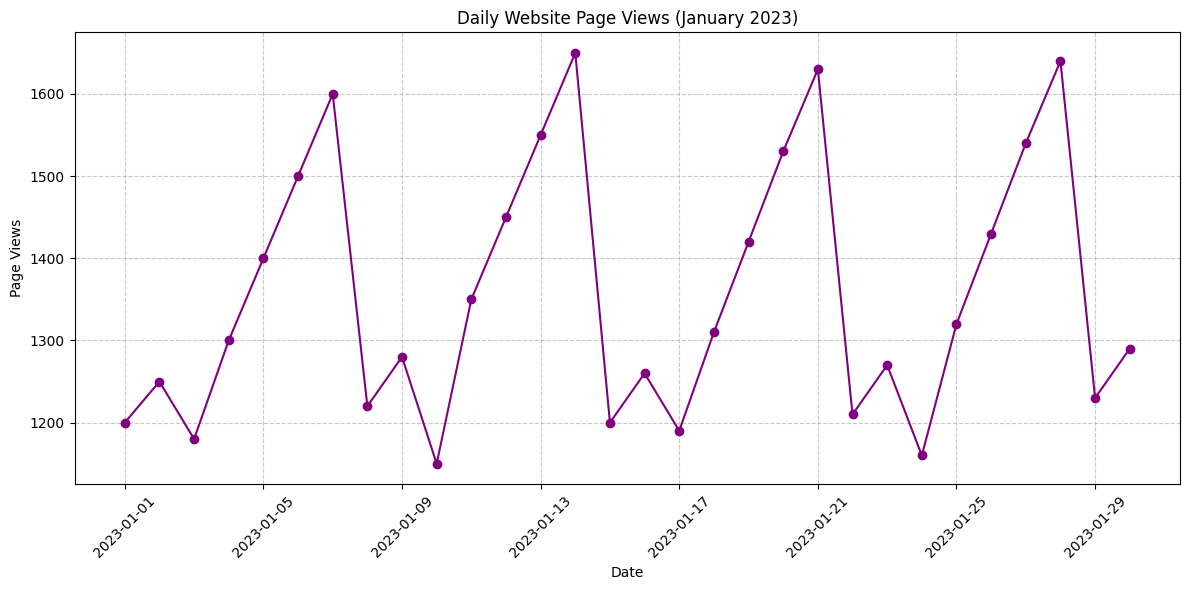

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df_ex3 = pd.DataFrame({
    'date': pd.date_range(start='2023-01-01', periods=30, freq='D'),
    'page_views': [1200, 1250, 1180, 1300, 1400, 1500, 1600, 1220, 1280, 1150,
                   1350, 1450, 1550, 1650, 1200, 1260, 1190, 1310, 1420, 1530,
                   1630, 1210, 1270, 1160, 1320, 1430, 1540, 1640, 1230, 1290]
})
df_ex3.set_index('date', inplace=True)

plt.figure(figsize=(12, 6))
plt.plot(df_ex3.index, df_ex3['page_views'], marker='o', linestyle='-', color='purple')
plt.title('Daily Website Page Views (January 2023)')
plt.xlabel('Date')
plt.ylabel('Page Views')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Exercise 4: Resampling and Aggregation for Monthly Analysis (Chart Analysis)

You have a DataFrame with daily energy consumption data for several months:

```python
import pandas as pd
import matplotlib.pyplot as plt

df_ex4 = pd.DataFrame({
    'timestamp': pd.date_range(start='2022-01-01', end='2022-06-30', freq='D'),
    'energy_kwh': [i + 50 + (i % 7) * 5 + (i % 30) * 2 + (i // 30) * 10 for i in range(181)]
})
df_ex4.set_index('timestamp', inplace=True)
```

(i) Write Python code to resample the `energy_kwh` data to a monthly frequency and calculate the *sum* of `energy_kwh` for each month.

(ii) Generate a bar chart to visualize the monthly total energy consumption. Add a clear title, axis labels, and ensure the x-axis labels (months) are readable.

(iii) Based on the bar chart, describe the trend in monthly energy consumption over the six-month period. Are there any seasonal patterns or a general increase/decrease?

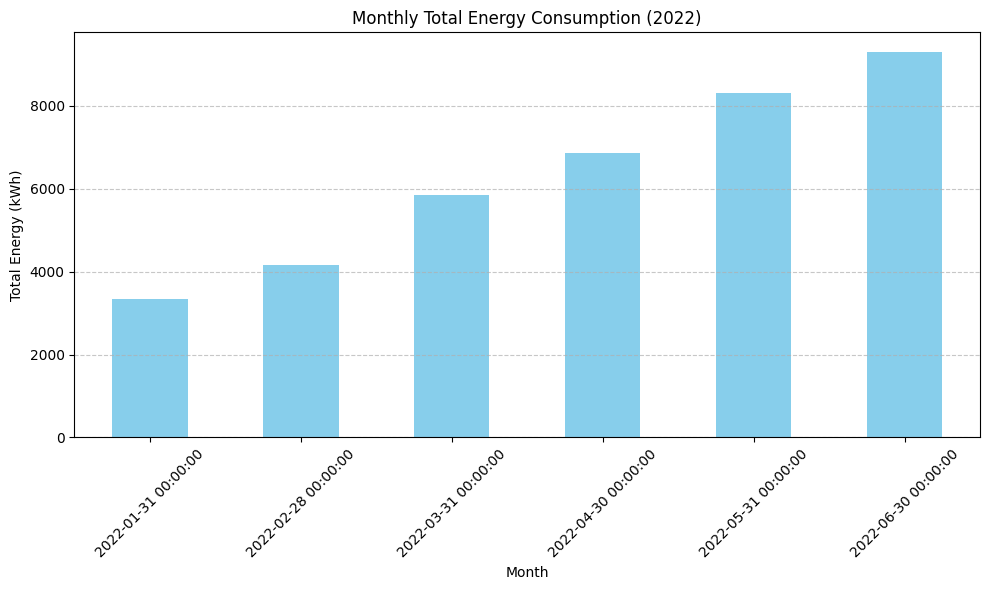

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df_ex4 = pd.DataFrame({
    'timestamp': pd.date_range(start='2022-01-01', end='2022-06-30', freq='D'),
    'energy_kwh': [i + 50 + (i % 7) * 5 + (i % 30) * 2 + (i // 30) * 10 for i in range(181)]
})
df_ex4.set_index('timestamp', inplace=True)

# (i) Resample to monthly frequency and calculate sum
monthly_energy_sum = df_ex4.resample('ME').sum()

# (ii) Generate a bar chart
plt.figure(figsize=(10, 6))
monthly_energy_sum['energy_kwh'].plot(kind='bar', color='skyblue')
plt.title('Monthly Total Energy Consumption (2022)')
plt.xlabel('Month')
plt.ylabel('Total Energy (kWh)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Exercise 5: Analyzing Daily Changes and Volatility (Chart Analysis)

Consider the following simulated stock price data:

```python
import pandas as pd
import matplotlib.pyplot as plt

df_ex5 = pd.DataFrame({
    'date': pd.date_range(start='2023-10-01', periods=20, freq='D'),
    'stock_price': [150.0, 152.5, 149.8, 153.2, 151.0, 155.5, 154.0, 157.0, 156.2, 160.0,
                    158.5, 161.0, 159.0, 162.5, 160.8, 164.0, 163.0, 165.5, 164.2, 167.0]
})
df_ex5.set_index('date', inplace=True)
```

(i) Write Python code to calculate the daily percentage change in `stock_price`.

(ii) Generate a line plot of these daily percentage changes. Set an appropriate title, axis labels, and add a horizontal line at y=0 to easily distinguish positive and negative changes.

(iii) Based on the plot, describe the volatility of the stock price during this period. Are there any periods of higher or lower change? What does the plot tell you about the daily returns?

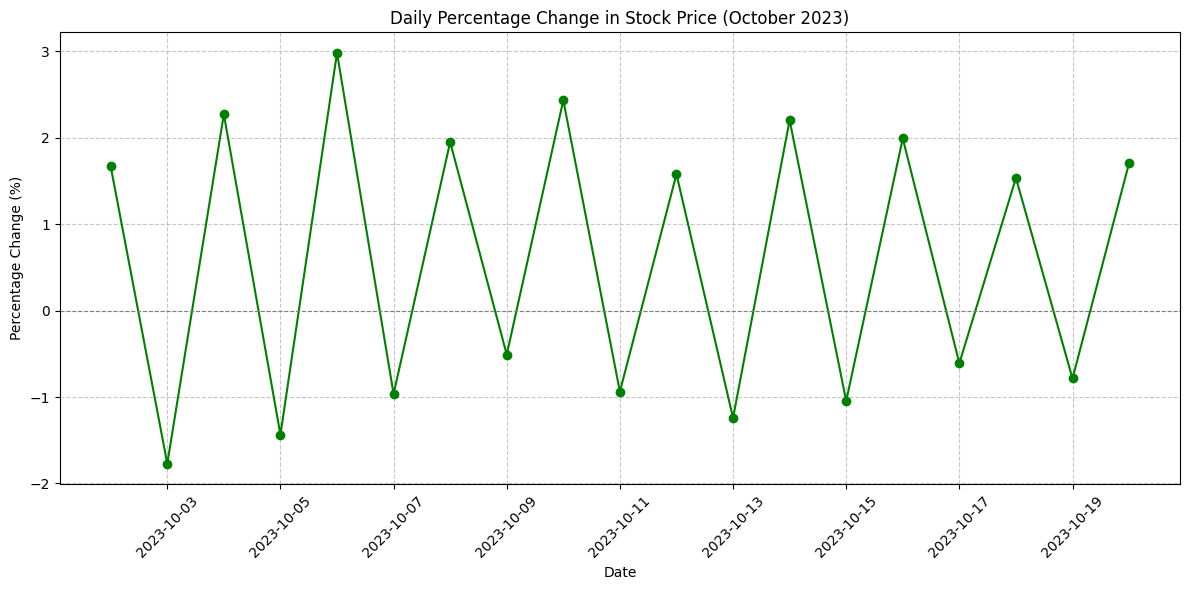

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df_ex5 = pd.DataFrame({
    'date': pd.date_range(start='2023-10-01', periods=20, freq='D'),
    'stock_price': [150.0, 152.5, 149.8, 153.2, 151.0, 155.5, 154.0, 157.0, 156.2, 160.0,
                    158.5, 161.0, 159.0, 162.5, 160.8, 164.0, 163.0, 165.5, 164.2, 167.0]
})
df_ex5.set_index('date', inplace=True)

# (i) Calculate daily percentage change
df_ex5['daily_pct_change'] = df_ex5['stock_price'].pct_change() * 100

# (ii) Generate a line plot of daily percentage changes
plt.figure(figsize=(12, 6))
plt.plot(df_ex5.index, df_ex5['daily_pct_change'], marker='o', linestyle='-', color='green')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8) # Add a horizontal line at y=0
plt.title('Daily Percentage Change in Stock Price (October 2023)')
plt.xlabel('Date')
plt.ylabel('Percentage Change (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()